# Macroeconomic Shocks and Sector Reactions

    Instead of looking at a single stock, look at the relationship between the broader economy and specific sectors. When a highly anomalous economic report is released (e.g., unexpected inflation spikes or unemployment jumps), how do different financial sectors (Tech vs. Energy vs. Healthcare) react over the following days?

### ***The Core Question***: Using anomaly detection on macroeconomic indicators, can we predict short-term volatility clustering in specific financial sectors?

In [1]:
from dotenv import load_dotenv
import os
import pandas as pd
from fredapi import Fred

load_dotenv()

# 1. Initialize the FRED API
# Replace 'YOUR_API_KEY_HERE' with your actual FRED API key
FRED_API_KEY = os.getenv('FRED_API_KEY')
# 1. Configuration
fred = Fred(api_key=FRED_API_KEY)

# Define our local storage directory and file name
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

def fetch_and_cache_fred_data(series_id, api_key, force_refresh=False):
    """
    Fetches archival 'first release' data for ANY series_id and caches it locally.
    Dynamically names columns based on the series_id for easy merging.
    """
    # Dynamic cache filename
    cache_file = os.path.join(DATA_DIR, f"{series_id.lower()}_first_releases.parquet")
    
    # 2. Check Local Cache
    if os.path.exists(cache_file) and not force_refresh:
        print(f"Success: Loading cached {series_id} data from {cache_file}...")
        return pd.read_parquet(cache_file)
        
    print(f"Cache not found. Fetching archival data for {series_id} from ALFRED...")
    try:
        # Pulling all historical revisions (Point-in-Time data)
        df = fred.get_series_all_releases(series_id)
    except Exception as e:
        print(f"API Error fetching {series_id}: {e}")
        return None
    
    # Standardize dates
    df['date'] = pd.to_datetime(df['date'])
    df['realtime_start'] = pd.to_datetime(df['realtime_start'])
    
    # Sort and isolate the first release (unrevised)
    df = df.sort_values(by=['date', 'realtime_start'])
    first_releases = df.drop_duplicates(subset=['date'], keep='first').copy()
    
    # 3. Dynamic Column Naming
    # This prevents column name collisions when you merge different indicators later.
    col_val = f"{series_id.lower()}_value"
    col_mom = f"{series_id.lower()}_mom_pct_change"
    
    first_releases = first_releases.rename(columns={
        'date': 'observation_date', 
        'realtime_start': 'release_date',
        'value': col_val
    })
    
    # Calculate the % Change (The shock factor)
    first_releases[col_mom] = first_releases[col_val].pct_change() * 100
    
    # Filter for thesis timeframe (Post-2000)
    first_releases = first_releases[first_releases['release_date'] >= '2000-08-01']
    
    # Select final columns
    final_df = first_releases[['observation_date', 'release_date', col_val, col_mom]].dropna()
    
    # 4. Save to Local Cache
    final_df.to_parquet(cache_file, index=False)
    print(f"Successfully saved {series_id} data to {cache_file}")
    
    return final_df

(Flannery, M. J., & Protopapadakis, A. A. (2002). Macroeconomic factors do influence aggregate stock returns. *The Review of Financial Studies*, 15(3), 751–782)

Two inflation measures (the CPI and the PPI) affect only the level of the market portfolio's returns. Three real fac-
tor candidates (Balance of Trade, Employment/Unemployment, and Housing Starts) affect only the returns' conditional volatility. A Monetary Aggregate
(generally Ml) affects both returns and conditional volatility

## We choose PPI as a first test indicator because:
    Surprise Potential: Because PPI is released relatively early in the month (usually before the final PCE numbers), it contains more "new" information, leading to higher information shocks.

In [2]:
ppi_df = fetch_and_cache_fred_data('PPIACO', FRED_API_KEY)

print("\n--- Dynamically Cached Data (PPI) ---")
print(ppi_df.head())

Success: Loading cached PPIACO data from data/ppiaco_first_releases.parquet...

--- Dynamically Cached Data (PPI) ---
  observation_date release_date  ppiaco_value  ppiaco_mom_pct_change
0       2000-07-01   2000-08-11         133.2              -0.075019
1       2000-08-01   2000-09-14         132.9              -0.225225
2       2000-09-01   2000-10-13         134.5               1.203913
3       2000-10-01   2000-11-09         135.1               0.446097
4       2000-11-01   2000-12-14         134.6              -0.370096


In [3]:
import yfinance as yf
import pandas as pd
import os

# Configuration
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)
SECTORS = {
    'Tech': 'XLK',
    'Energy': 'XLE',
    'Healthcare': 'XLV'
}
START_DATE = '2000-01-01'
ETFS_CACHE = f'{DATA_DIR}/sector_event_windows.parquet'

def fetch_and_cache_event_windows(sectors, start_date, force_refresh=False):
    if os.path.exists(ETFS_CACHE) and not force_refresh:
        print(f"Success: Loading cached ETF event windows from {ETFS_CACHE}...")
        return pd.read_parquet(ETFS_CACHE)
    
    print("Fetching ETF data and calculating event windows...")
    all_returns = []
    
    for sector_name, ticker in sectors.items():
        print(f"Processing {sector_name} ({ticker})...")
        
        # Download one by one to avoid MultiIndex KeyErrors
        df = yf.download(ticker, start=start_date, progress=False)
        
        # Ensure column names are standard strings, not tuples (handles yfinance edge cases)
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
        
        # 1. Same-Day Return: (Close_today - Close_yesterday) / Close_yesterday
        df['Return_1D'] = df['Close'].pct_change()
        
        # 2. Overnight Return: (Open_today - Close_yesterday) / Close_yesterday
        df['Return_Overnight'] = (df['Open'] / df['Close'].shift(1)) - 1
        
        # 3. 3-Day Cumulative Return: (Close_day+2 - Close_yesterday) / Close_yesterday
        # We use shift(-2) to look forward two days into the future
        df['Return_3D'] = (df['Close'].shift(-2) / df['Close'].shift(1)) - 1
        
        # Add metadata
        df['Sector'] = sector_name
        df['Ticker'] = ticker
        
        # Clean up and keep only what we need
        features = df[['Return_1D', 'Return_Overnight', 'Return_3D', 'Sector', 'Ticker']].dropna()
        all_returns.append(features)
        
    # Combine everything into one pristine DataFrame
    combined_df = pd.concat(all_returns).reset_index()
    
    # Standardize the date column name for our upcoming merge
    combined_df = combined_df.rename(columns={'Date': 'date'})
    
    # Save to Parquet
    print(f"Saving event windows to {ETFS_CACHE}...")
    combined_df.to_parquet(ETFS_CACHE, index=False)
    
    return combined_df

In [4]:
# Execute
sector_events_df = fetch_and_cache_event_windows(SECTORS, START_DATE)

print("\n--- Event Windows Data ---")
# Let's look at the Tech sector specifically to verify
print(sector_events_df[sector_events_df['Sector'] == 'Tech'].head())

Success: Loading cached ETF event windows from data/sector_event_windows.parquet...

--- Event Windows Data ---
        date  Return_1D  Return_Overnight  Return_3D Sector Ticker
0 2000-01-04  -0.050733         -0.025930  -0.095829   Tech    XLK
1 2000-01-05  -0.014846         -0.016627  -0.030879   Tech    XLK
2 2000-01-06  -0.033152         -0.011452   0.021098   Tech    XLK
3 2000-01-07   0.017456         -0.009975   0.026184   Tech    XLK
4 2000-01-10   0.037990          0.039216   0.004289   Tech    XLK


## Phase 2: Volatility Clustering and ARCH-LM Testing (XLK)

Following the initial macroeconomic data extraction, we now focus exclusively on the **Technology Select Sector SPDR ETF (XLK)**. Before fitting complex GARCH or LSTM models, we must statistically justify their necessity. 

Financial time series often exhibit **volatility clustering**—periods of high turbulence followed by high turbulence, and periods of calm followed by calm. 

**Objectives for this section:**
1. Download daily Adjusted Close prices for XLK.
2. Calculate daily logarithmic returns and squared returns.
3. Visually inspect the return series and squared return series.
4. Plot the Autocorrelation Function (ACF) of squared returns to check for persistence in variance.
5. Perform the **ARCH-LM (Engle's Lagrange Multiplier) Test** to formally reject the null hypothesis of constant variance (homoskedasticity).

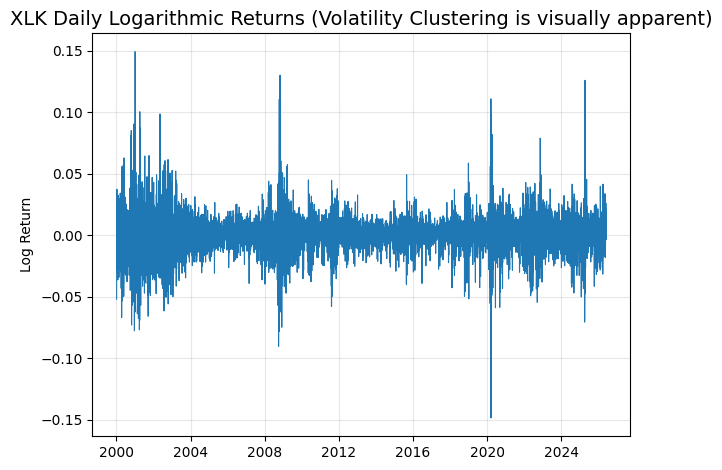

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch

# 1. Download XLK daily closing prices (Adjusted Close)
TICKER = 'XLK'
START_DATE = '2000-01-01'

print(f"Downloading {TICKER} data...")
xlk_df = yf.download(TICKER, start=START_DATE, progress=False)

# Handle yfinance MultiIndex columns if present
if isinstance(xlk_df.columns, pd.MultiIndex):
    xlk_df.columns = xlk_df.columns.get_level_values(0)

# 2. Calculate daily logarithmic returns & squared returns
# Using Adjusted Close to account for dividends and splits
xlk_df['Log_Return'] = np.log(xlk_df['Close'] / xlk_df['Close'].shift(1))
xlk_df = xlk_df.dropna().copy()

xlk_df['Sq_Log_Return'] = xlk_df['Log_Return'] ** 2

# 3 & 5. Plotting Returns and Squared Returns
# fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Log Returns
plt.plot(xlk_df.index, xlk_df['Log_Return'], color='#1f77b4', linewidth=0.8)
plt.title(f"{TICKER} Daily Logarithmic Returns (Volatility Clustering is visually apparent)", fontsize=14)
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


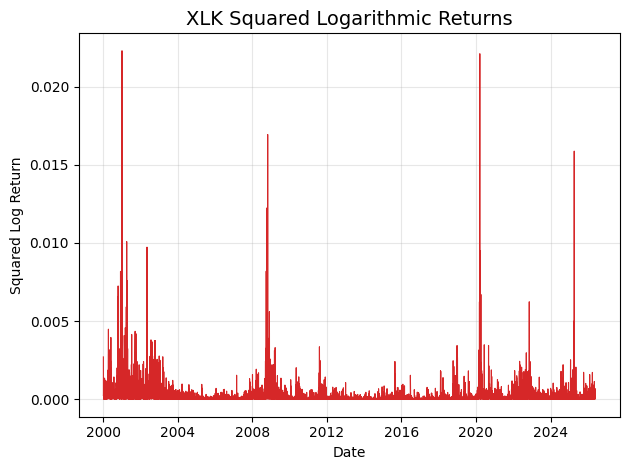

In [6]:
# Plot Squared Returns (Proxy for Volatility)
plt.plot(xlk_df.index, xlk_df['Sq_Log_Return'], color='#d62728', linewidth=0.8)
plt.title(f"{TICKER} Squared Logarithmic Returns", fontsize=14)
plt.ylabel("Squared Log Return")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


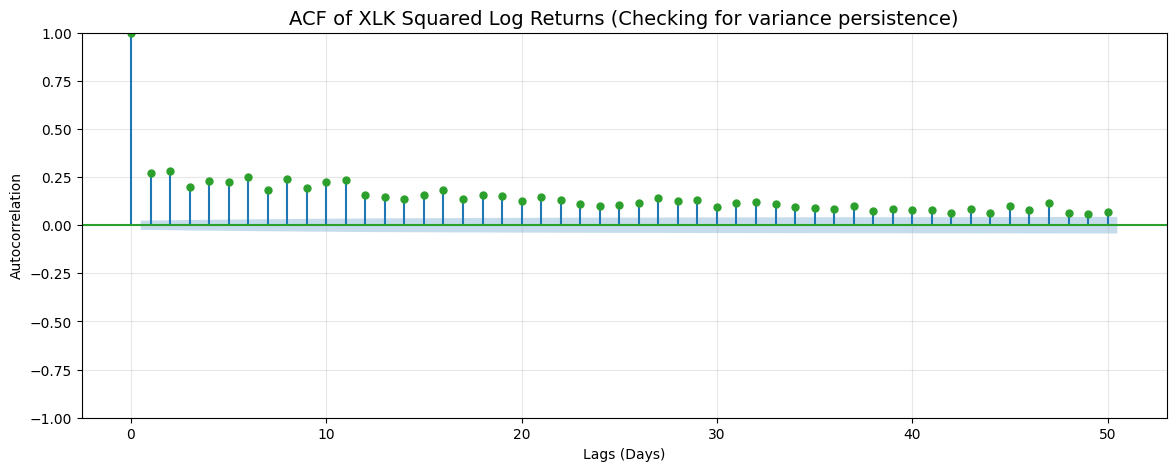


ARCH-LM Test Results for XLK
Lagrange Multiplier (LM) Stat: 1017.5617
LM Test p-value:               9.4782e-218
F-Statistic:                   240.1599
F-Test p-value:                1.9493e-236
----------------------------------------
Conclusion: Reject the null hypothesis of no ARCH effects.
Interpretation: Strong statistical evidence of volatility clustering.
Next Step: Proceeding with GARCH family models is highly justified.


In [7]:
# 6. Plot ACF of Squared Returns
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(xlk_df['Sq_Log_Return'], lags=50, ax=ax, color='#2ca02c')
ax.set_title(f"ACF of {TICKER} Squared Log Returns (Checking for variance persistence)", fontsize=14)
ax.set_xlabel("Lags (Days)")
ax.set_ylabel("Autocorrelation")
ax.grid(True, alpha=0.3)
plt.show()

# 7. ARCH-LM Test
# The test is usually applied to the residuals of a mean model. 
# We subtract the mean of the returns to get the residuals (assuming a constant mean equation).
returns_mean_adj = xlk_df['Log_Return'] - xlk_df['Log_Return'].mean()

# Perform the test up to 5 lags
# Returns: LM statistic, p-value, f-statistic, f p-value
lm_stat, p_value, f_stat, fp_value = het_arch(returns_mean_adj, nlags=5)

print("\n" + "="*40)
print(f"ARCH-LM Test Results for {TICKER}")
print("="*40)
print(f"Lagrange Multiplier (LM) Stat: {lm_stat:.4f}")
print(f"LM Test p-value:               {p_value:.4e}")
print(f"F-Statistic:                   {f_stat:.4f}")
print(f"F-Test p-value:                {fp_value:.4e}")
print("-" * 40)

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis of no ARCH effects.")
    print("Interpretation: Strong statistical evidence of volatility clustering.")
    print("Next Step: Proceeding with GARCH family models is highly justified.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
    print("Interpretation: No significant evidence of ARCH effects found.")

In [8]:
import os
import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
from arch import arch_model
from dotenv import load_dotenv

# ---------------------------------------------------------
# 1. Setup & Configuration
# ---------------------------------------------------------
load_dotenv()
FRED_API_KEY = os.getenv('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

# Assuming xlk_df from the previous step is still in memory. 
# If not, we isolate the returns we calculated:
# We scale returns by 100 (percentages) which helps GARCH optimization converge
returns = xlk_df['Log_Return'].dropna() * 100 

# ---------------------------------------------------------
# 2. Fit Volatility Models (ARCH, GARCH, EGARCH)
# ---------------------------------------------------------
print("Fitting Volatility Models...")

# ARCH(1)
print("Fitting ARCH(1)...")
arch_mod = arch_model(returns, vol='ARCH', p=1, mean='Constant')
arch_res = arch_mod.fit(disp='off')
xlk_df['Vol_ARCH'] = arch_res.conditional_volatility

# GARCH(1,1)
print("Fitting GARCH(1,1)...")
garch_mod = arch_model(returns, vol='GARCH', p=1, q=1, mean='Constant')
garch_res = garch_mod.fit(disp='off')
xlk_df['Vol_GARCH'] = garch_res.conditional_volatility

# EGARCH(1,1,1) - Accounts for asymmetric shocks (leverage effect)
print("Fitting EGARCH(1,1)...")
egarch_mod = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, mean='Constant')
egarch_res = egarch_mod.fit(disp='off')
xlk_df['Vol_EGARCH'] = egarch_res.conditional_volatility

print("\nModel Fitting Complete. Extracted Conditional Volatilities.")


Fitting Volatility Models...
Fitting ARCH(1)...
Fitting GARCH(1,1)...
Fitting EGARCH(1,1)...

Model Fitting Complete. Extracted Conditional Volatilities.


In [9]:

# ---------------------------------------------------------
# 3. Fetch Macroeconomic Variables
# ---------------------------------------------------------
print("\nFetching Macroeconomic Data...")
start_date = xlk_df.index.min().strftime('%Y-%m-%d')

# A. Daily Market Macro (yfinance)
# VIX (Volatility Index) and CL=F (Crude Oil WTI)
macro_tickers = {'VIX': '^VIX', 'Oil_WTI': 'CL=F'}
daily_macro = yf.download(list(macro_tickers.values()), start=start_date, progress=False)['Close']
daily_macro.columns = list(macro_tickers.keys())

# Calculate daily shocks/changes for VIX and Oil
daily_macro['VIX_Change'] = daily_macro['VIX'].pct_change()
daily_macro['Oil_Change'] = daily_macro['Oil_WTI'].pct_change()

# B. Monthly Economic Indicators (FRED)
# CPIAUCSL (CPI), FEDFUNDS (Interest Rate), UNRATE (Unemployment)
fred_series = {
    'CPI': 'CPIAUCSL',
    'FedFunds': 'FEDFUNDS',
    'Unemployment': 'UNRATE'
}

fred_data = {}
for name, series_id in fred_series.items():
    try:
        # Fetch data and convert to dataframe
        series = fred.get_series(series_id, observation_start=start_date)
        df = pd.DataFrame(series, columns=[name])
        # Calculate Month-over-Month (MoM) change/shock
        if name == 'CPI':
            df[f'{name}_MoM'] = df[name].pct_change() * 100
        else:
            # For rates, absolute difference is often preferred over pct_change
            df[f'{name}_Diff'] = df[name].diff() 
        
        fred_data[name] = df
    except Exception as e:
        print(f"Error fetching {name} from FRED: {e}")

# Combine FRED data
monthly_macro = pd.concat(fred_data.values(), axis=1)

# ---------------------------------------------------------
# 4. Merge Everything into a Master Feature Dataset
# ---------------------------------------------------------
# Merge Daily Macro (VIX, Oil) first
master_df = xlk_df.join(daily_macro, how='left')

# Merge Monthly Macro (FRED)
# Since FRED data is monthly (usually 1st of the month), we use forward-fill ('ffill')
# to apply the latest available monthly report data to our daily trading days.
master_df = master_df.join(monthly_macro, how='left').ffill()

# Drop initial NaNs caused by percentage changes and differing start dates
master_df = master_df.dropna()

print("\n--- Master Dataset Ready for LSTM ---")
print(master_df[['Log_Return', 'Vol_GARCH', 'VIX_Change', 'CPI_MoM', 'FedFunds_Diff']].head())

# Optional: Save to parquet for the LSTM notebook
# master_df.to_parquet('data/xlk_garch_macro_features.parquet')


Fetching Macroeconomic Data...



--- Master Dataset Ready for LSTM ---
            Log_Return  Vol_GARCH  VIX_Change  CPI_MoM  FedFunds_Diff
Date                                                                 
2000-08-24    0.009337   1.303337   -0.013105      0.0          -0.04
2000-08-25   -0.003385   1.268046    0.013279      0.0          -0.04
2000-08-28    0.008161   1.212685    0.025585      0.0          -0.04
2000-08-29    0.001120   1.177455   -0.004563      0.0          -0.04
2000-08-30   -0.006741   1.120740    0.020782      0.0          -0.04


In [10]:
# 1. Define the continuous proxy (Future Squared Returns)
master_df['Future_Sq_Return'] = master_df['Sq_Log_Return'].shift(-1)

# Drop the final row since we don't have "tomorrow's" data for it
master_df = master_df.dropna().copy()

# 2. Define Regime Thresholds
# Class 0: Calm (0 to 50th percentile)
# Class 1: Elevated (50th to 85th percentile)
# Class 2: High Volatility / Shock (Top 15%)
thresh_50 = master_df['Future_Sq_Return'].quantile(0.50)
thresh_85 = master_df['Future_Sq_Return'].quantile(0.85)

def classify_regime(val):
    if val <= thresh_50:
        return 0
    elif val <= thresh_85:
        return 1
    else:
        return 2

# 3. Apply the classification
master_df['Target_Regime'] = master_df['Future_Sq_Return'].apply(classify_regime)

print("--- Regime Thresholds ---")
print(f"50th Percentile (Calm/Elevated boundary): {thresh_50:.6f}")
print(f"85th Percentile (Elevated/Shock boundary): {thresh_85:.6f}")
print("\n--- Class Distribution ---")
print(master_df['Target_Regime'].value_counts(normalize=True).sort_index() * 100)

--- Regime Thresholds ---
50th Percentile (Calm/Elevated boundary): 0.000052
85th Percentile (Elevated/Shock boundary): 0.000392

--- Class Distribution ---
Target_Regime
0    50.007720
1    34.985333
2    15.006948
Name: proportion, dtype: float64


> [!IMPORTANT] About threshold 
:The threshold needs to be rolling!!!

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ---------------------------------------------------------
# 1. Dataset Preparation 
# ---------------------------------------------------------
class RegimeDataset(Dataset):
    def __init__(self, features, target, sequence_length):
        self.features = torch.tensor(features, dtype=torch.float32)
        # CRITICAL: Target must be 'long' (integer) for CrossEntropyLoss
        self.target = torch.tensor(target, dtype=torch.long) 
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx : idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return x, y

# ---------------------------------------------------------
# 2. Multi-Class LSTM Architecture
# ---------------------------------------------------------
class HybridRegimeLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes=3, dropout=0.2):
        super(HybridRegimeLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        # Output layer maps to our 3 classes
        self.fc2 = nn.Linear(16, num_classes)
        
        # NOTE: We do not apply Softmax here because PyTorch's CrossEntropyLoss 
        # expects raw, unnormalized logits and applies LogSoftmax internally.

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] # Decode last time step
        
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out) # Returns shape: (batch_size, 3)
        
        return out

# ---------------------------------------------------------
# 3. Classification Training Loop
# ---------------------------------------------------------
def train_classification_model(model, train_loader, epochs=50, lr=0.001):
    # CrossEntropyLoss is standard for multi-class classification
    criterion = nn.CrossEntropyLoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass: outputs are logits shape (batch, 3)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            # Backward and optimize
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Calculate accuracy
            # Get the index of the max logit (0, 1, or 2)
            _, predicted_classes = torch.max(logits, dim=1) 
            correct_predictions += (predicted_classes == batch_y).sum().item()
            total_samples += batch_y.size(0)
            
        if (epoch+1) % 10 == 0:
            avg_loss = total_loss / len(train_loader)
            accuracy = (correct_predictions / total_samples) * 100
            print(f'Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%')
            
    return model

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Chronological Train / Test Split
# ---------------------------------------------------------
print("Preparing Data...")
# Define the features we want to use (adjust based on what we engineered earlier)
feature_cols = ['Log_Return', 'Vol_GARCH', 'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff']
target_col = 'Target_Regime'

# We must split chronologically (e.g., first 80% of time for training, last 20% for testing)
split_idx = int(len(master_df) * 0.8)

train_df = master_df.iloc[:split_idx].copy()
test_df = master_df.iloc[split_idx:].copy()

print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")

# ---------------------------------------------------------
# 2. Feature Scaling & DataLoaders
# ---------------------------------------------------------
# Neural networks require scaled features. We fit the scaler ONLY on the training data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[feature_cols])
X_test_scaled = scaler.transform(test_df[feature_cols])

y_train = train_df[target_col].values
y_test = test_df[target_col].values

SEQUENCE_LENGTH = 21 # Lookback of roughly one trading month

# Create Datasets (Using the RegimeDataset class we defined previously)
train_dataset = RegimeDataset(X_train_scaled, y_train, SEQUENCE_LENGTH)
test_dataset = RegimeDataset(X_test_scaled, y_test, SEQUENCE_LENGTH)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False) # Shuffle=False is safer for time series batches
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ---------------------------------------------------------
# 3. Calculate Class Weights for Imbalance
# ---------------------------------------------------------
# 'balanced' automatically calculates weights inversely proportional to class frequencies
class_weights_arr = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Convert weights to PyTorch tensor and move to GPU/CPU
weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

print("\n--- Calculated Class Weights ---")
print(f"Class 0 (Calm):     {weights_tensor[0]:.4f}")
print(f"Class 1 (Elevated): {weights_tensor[1]:.4f}")
print(f"Class 2 (Shock):    {weights_tensor[2]:.4f}")

# ---------------------------------------------------------
# 4. Initialize Model and Weighted Loss
# ---------------------------------------------------------
# Instantiating the HybridRegimeLSTM we built previously
model = HybridRegimeLSTM(
    input_size=len(feature_cols), 
    hidden_size=32, 
    num_layers=2, 
    num_classes=3
).to(device)

# HERE IS THE MAGIC: We pass the weights into the CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------------
# 5. Training Loop
# ---------------------------------------------------------
EPOCHS = 500
print("\nStarting Training...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Average Loss: {total_loss/len(train_loader):.4f}")

# ---------------------------------------------------------
# 6. The First Test (Evaluation)
# ---------------------------------------------------------
print("\n" + "="*40)
print("Evaluating on Unseen Test Data")
print("="*40)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        
        # Get the predicted class (0, 1, or 2)
        _, preds = torch.max(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch_y.numpy())

# Generate a Classification Report
print(classification_report(
    all_targets, 
    all_preds, 
    target_names=['Class 0 (Calm)', 'Class 1 (Elevated)', 'Class 2 (Shock)'],
    zero_division=0
))

Preparing Data...
Training Samples: 5181 | Testing Samples: 1296

--- Calculated Class Weights ---
Class 0 (Calm):     0.6411
Class 1 (Elevated): 0.9954
Class 2 (Shock):    2.2965

Starting Training...


Epoch [10/500] | Average Loss: 0.9171


Epoch [20/500] | Average Loss: 0.9040


Epoch [30/500] | Average Loss: 0.8873


Epoch [40/500] | Average Loss: 0.8623


...

Epoch [460/500] | Average Loss: 0.2440


Epoch [470/500] | Average Loss: 0.2386


Epoch [480/500] | Average Loss: 0.2293


Epoch [490/500] | Average Loss: 0.2869


Epoch [500/500] | Average Loss: 0.2317

Evaluating on Unseen Test Data
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.45      0.49      0.47       538
Class 1 (Elevated)       0.40      0.35      0.37       519
   Class 2 (Shock)       0.28      0.30      0.29       218

          accuracy                           0.40      1275
         macro avg       0.37      0.38      0.37      1275
      weighted avg       0.40      0.40      0.40      1275



========================================
Evaluating on Unseen Test Data
========================================
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.48      0.43      0.46       538
Class 1 (Elevated)       0.41      0.38      0.39       519
   Class 2 (Shock)       0.24      0.35      0.29       218

          accuracy                           0.40      1275
         macro avg       0.38      0.39      0.38      1275
      weighted avg       0.41      0.40      0.40      1275
